In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
import fiftyone as fo

## list all dataset
print(fo.list_datasets())

# Close any zombie sessions that might be hanging
fo.close_app()

['dugong']


In [3]:
len(list(dataset.get_field_schema().keys()))

57

# Meeting 27-04-26

In [2]:
# load dataset
dataset = fo.load_dataset("dugong")


In [4]:
dataset

Name:        dugong
Media type:  image
Num samples: 2755
Persistent:  True
Tags:        []
Sample fields:
    id:                                             fiftyone.core.fields.ObjectIdField
    filepath:                                       fiftyone.core.fields.StringField
    tags:                                           fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                                       fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                                     fiftyone.core.fields.DateTimeField
    last_modified_at:                               fiftyone.core.fields.DateTimeField
    region:                                         fiftyone.core.fields.StringField
    subregion:                                      fiftyone.core.fields.StringField
    mission_name:                                   fiftyone.core.fields.StringField
    sea_state:                             

In [5]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import json
from fiftyone import ViewField as F
import matplotlib.pyplot as plt
import numpy as np



In [6]:
dataset.match(F("region")=="NC")

Dataset:     dugong
Media type:  image
Num samples: 716
Sample fields:
    id:                                             fiftyone.core.fields.ObjectIdField
    filepath:                                       fiftyone.core.fields.StringField
    tags:                                           fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                                       fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                                     fiftyone.core.fields.DateTimeField
    last_modified_at:                               fiftyone.core.fields.DateTimeField
    region:                                         fiftyone.core.fields.StringField
    subregion:                                      fiftyone.core.fields.StringField
    mission_name:                                   fiftyone.core.fields.StringField
    sea_state:                                      fiftyone.core.fields.IntFi

In [22]:

# PARTITIONS_NC = np.floor(np.linspace(0,1,11)*760).astype('int64')
# PARTITIONS_NC
np.array(np.linspace(0,1,11))*np.array([0.7]).reshape(-1)

array([0.  , 0.07, 0.14, 0.21, 0.28, 0.35, 0.42, 0.49, 0.56, 0.63, 0.7 ])

In [3]:
## load the views
nc_view = dataset.load_saved_view("nc")
wp_view = dataset.load_saved_view("wp")
## launch session
session = fo.launch_app(dataset,
                        port=5151,
                        auto=False)

Session launched. Run `session.show()` to open the App in a cell output.


In [23]:
dataset.count_values('new_stratify_key')

{'WP_UM_UM_M6': 269,
 'WP_FRIWEN_FRIWEN_M11': 335,
 'NC_only': 716,
 'WP_UM_UM_M3': 4,
 'WP_FRIWEN_FRIWEN_M19': 14,
 'WP_GAM_GAM_M1': 211,
 'WP_FRIWEN_FRIWEN_M8': 222,
 'WP_UM_UM_M5': 449,
 'WP_MANTASANDY_MANTASANDY_M5': 3,
 'WP_UM_UM_M2': 9,
 'WP_UM_UM_M1': 14,
 'WP_FRIWEN_FRIWEN_M53': 4,
 'WP_GAM_GAM_M2': 275,
 'WP_GAM_GAM_M10': 26,
 'WP_FRIWEN_FRIWEN_M12': 204}

In [24]:
dataset.count_values('stratify_key')

{'WP_FRIWEN_FRIWEN_M53': 4,
 'NC_NC_Flight_215': 37,
 'NC_NC_Flight_213': 41,
 'WP_FRIWEN_FRIWEN_M12': 204,
 'WP_FRIWEN_FRIWEN_M8': 222,
 'NC_NC_Flight_218': 22,
 'NC_NC_Flight_235': 4,
 'NC_NC_Flight_219': 23,
 'WP_UM_UM_M1': 14,
 'NC_NC_Flight_226': 5,
 'NC_NC_Flight_198': 73,
 'NC_NC_Flight_231': 12,
 'NC_NC_Flight_209': 83,
 'NC_NC_Flight_222': 17,
 'WP_UM_UM_M3': 4,
 'WP_FRIWEN_FRIWEN_M19': 14,
 'NC_NC_Flight_214': 19,
 'NC_NC_Flight_211': 17,
 'NC_NC_Flight_212': 36,
 'NC_NC_Flight_200': 10,
 'NC_NC_Flight_232': 23,
 'WP_GAM_GAM_M10': 26,
 'NC_NC_Flight_197': 50,
 'WP_GAM_GAM_M2': 275,
 'WP_UM_UM_M6': 269,
 'NC_NC_Flight_195': 6,
 'NC_NC_Flight_234': 2,
 'NC_NC_Flight_196': 63,
 'NC_NC_Flight_220': 20,
 'WP_MANTASANDY_MANTASANDY_M5': 3,
 'WP_UM_UM_M2': 9,
 'NC_NC_Flight_207': 128,
 'NC_NC_Flight_199': 8,
 'WP_GAM_GAM_M1': 211,
 'WP_UM_UM_M5': 449,
 'NC_NC_Flight_205': 9,
 'NC_NC_Flight_225': 2,
 'WP_FRIWEN_FRIWEN_M11': 335,
 'NC_NC_Flight_233': 6}

In [14]:
dataset.match_tags('test_10').distinct('stratify_key')

['NC_NC_Flight_197',
 'NC_NC_Flight_212',
 'NC_NC_Flight_220',
 'NC_NC_Flight_234',
 'WP_GAM_GAM_M1',
 'WP_UM_UM_M6']

In [6]:
## Match the TEST set of WP
field_name_test_set = "test_10"
wp_test_set = (dataset
                .match_tags(field_name_test_set)
               .match(F("region")=="WP")
               )

print(f"Number of iamges on test size:{len(wp_test_set)}")
print(f"Unique flight mission used for test:{wp_test_set.distinct('mission_name')}")

Number of iamges on test size:59
Unique flight mission used for test:['GAM_M1', 'UM_M6']


In [18]:
## All other flights used for train/val
(dataset
    .match_tags('val_10')
    .match(F("region")=="WP")
).distinct("mission_name")

['FRIWEN_M11',
 'FRIWEN_M12',
 'FRIWEN_M53',
 'FRIWEN_M8',
 'GAM_M10',
 'GAM_M2',
 'MANTASANDY_M5',
 'UM_M1',
 'UM_M2',
 'UM_M3',
 'UM_M5']

In [7]:
session.view = wp_test_set

In [20]:
dataset.distinct('tags')

['notin_TEST_0',
 'notin_TEST_10',
 'notin_TEST_6',
 'notin_val_0',
 'notin_val_10',
 'notin_val_6',
 'test_0',
 'test_10',
 'test_6',
 'train_0',
 'train_10',
 'train_6',
 'val_0',
 'val_10',
 'val_6']

In [21]:
wp_view.match_tags('notin_TEST_10').count_values("stratify_key")

{'WP_GAM_GAM_M1': 187, 'WP_UM_UM_M6': 234}

In [22]:
wp_view.match_tags('test_10').count_values("stratify_key")

{'WP_UM_UM_M6': 35, 'WP_GAM_GAM_M1': 24}

# The art of unexpected

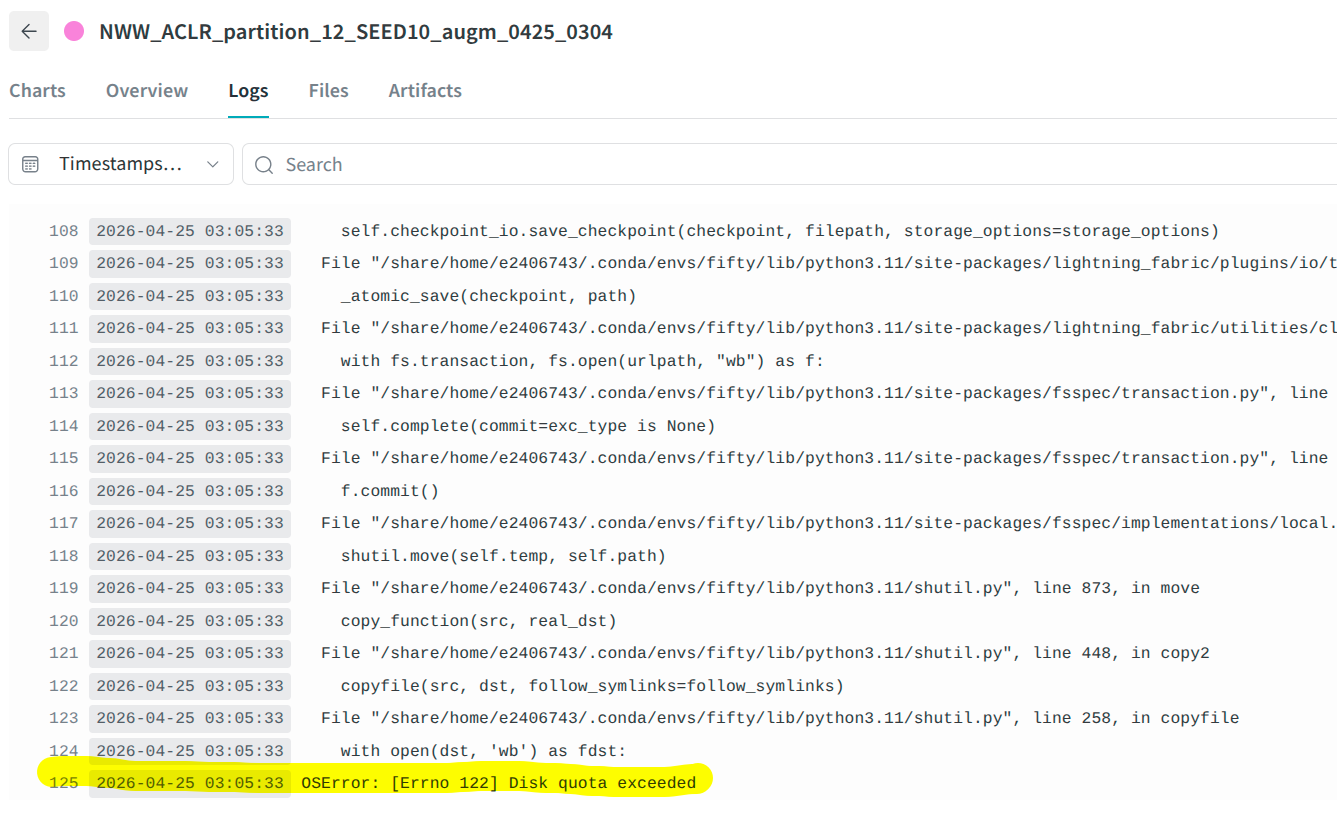

# Subset Characteristics of the first run

- General Idea: Select differerent Subsets of WP (e.g 1000 samples) and apply the ratio 90:10 (train/test) with 85:15 (train/val). The subset can the further subset into smaller train partition (5%, 10%, 25%, 50%)

- Seed number = 10 
- Flight missions on test set = ['GAM_M1', 'UM_M6']
- Flight missions on train/val = all others flights
- Total Subset = 750
- Number of Train images: 600 (images) (if full set) (60 images if 10% of the subset)
- Number of Val images: 105
- Number of Test images: 59
- RATIO: ~ 80:10:10



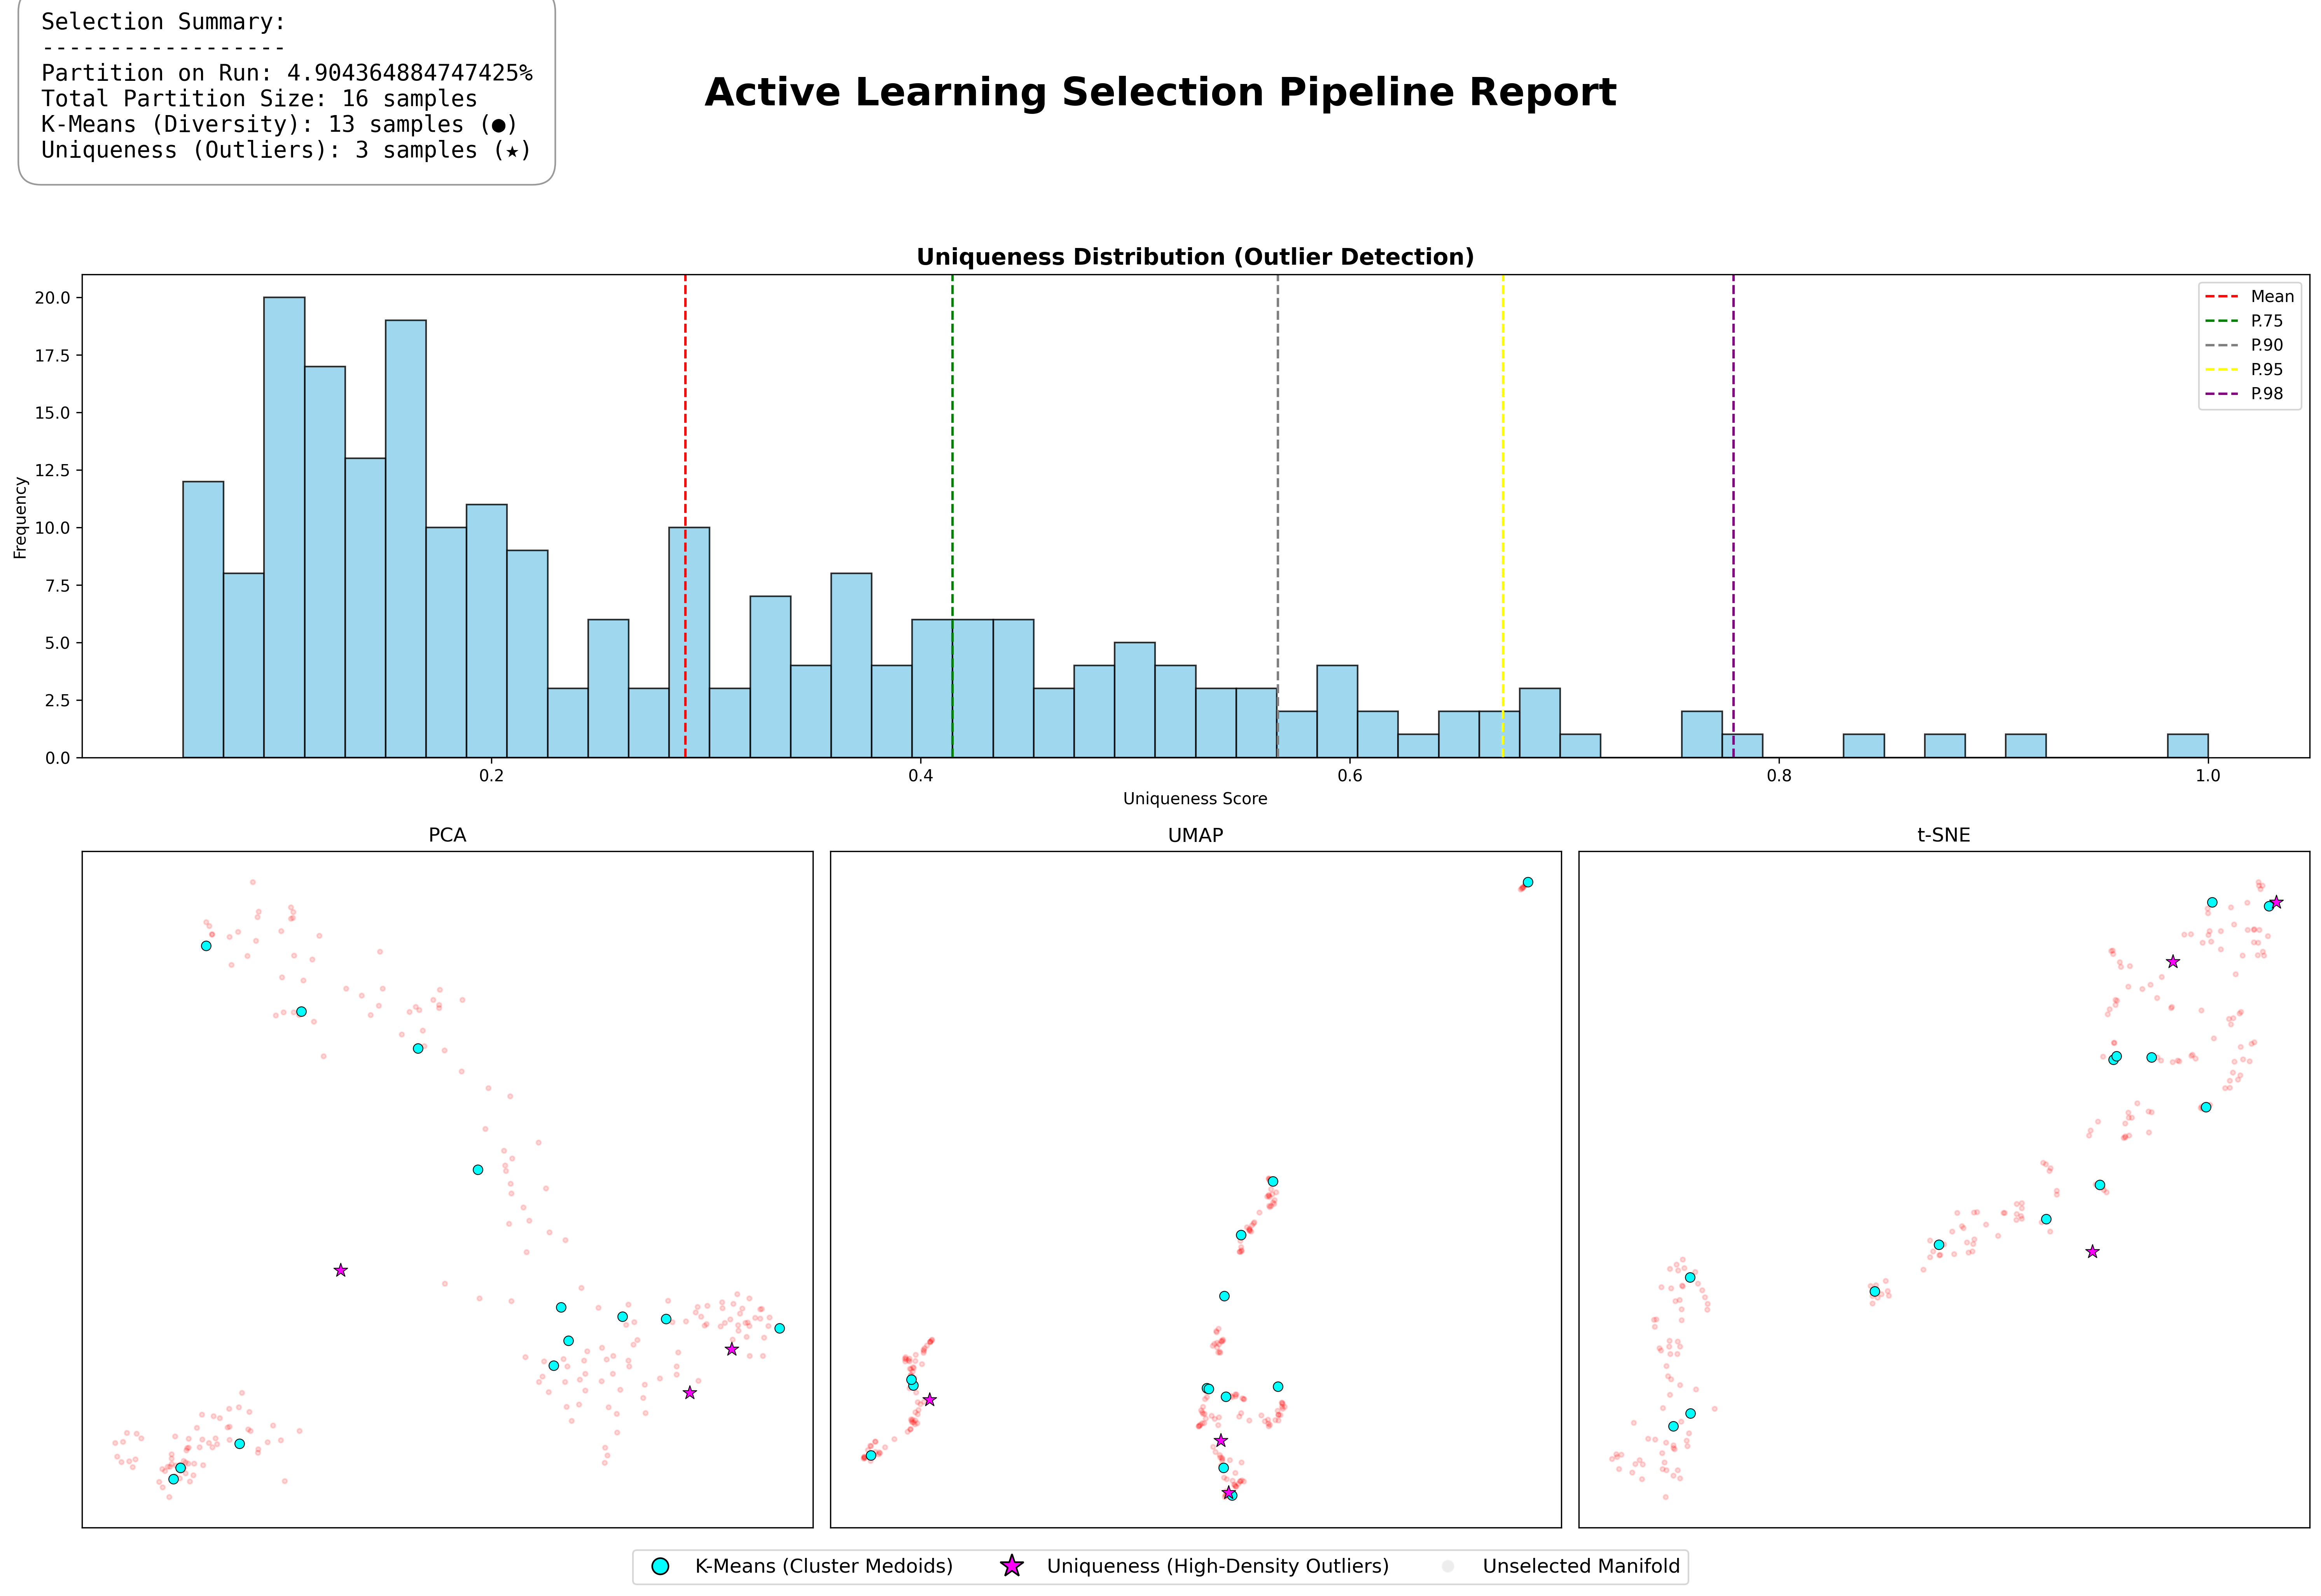

# Results

In [25]:
models = [
    {
        "pred_field": "NNN_predWP_SEED10_raw",
        "eval_key":   "eval_baseline_s10",
    },
    {
        "pred_field": "NWW_partition_4_SEED10_augm_0424_1304_raw",
        "eval_key":   "eval_ft_s10",
    },
    {
        "pred_field": "NWW_ACLR_partition_4_SEED10_augm_0425_0240_raw",
        "eval_key":   "eval_ft_aclr_s10",
    },
]

# --- Run evaluations ---
results = {}
for m in models:
    results[m["eval_key"]] = wp_test_set.evaluate_detections(
        m["pred_field"],
        gt_field="ground_truth",
        eval_key=m["eval_key"],
        method="coco",          # COCO-style mAP
        iou=0.5,
        classwise=False,        # single class (dugong), no need to enforce classwise
        compute_mAP=True,
    )

Evaluating detections...
 100% |███████████████████| 59/59 [505.0ms elapsed, 0s remaining, 116.8 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 59/59 [418.6ms elapsed, 0s remaining, 141.0 samples/s]      
Evaluating detections...
 100% |███████████████████| 59/59 [714.7ms elapsed, 0s remaining, 82.6 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 59/59 [626.3ms elapsed, 0s remaining, 94.2 samples/s]      
Evaluating detections...
 100% |███████████████████| 59/59 [693.0ms elapsed, 0s remaining, 85.1 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 59/59 [613.5ms elapsed, 0s remaining, 96.2 samples/s]      


In [26]:
# reload evaluations
models = [
    {
        "pred_field": "NNN_predWP_SEED10_raw",
        "eval_key":   "eval_baseline_s10",
    },
    {
        "pred_field": "NWW_partition_4_SEED10_augm_0424_1304_raw",
        "eval_key":   "eval_ft_s10",
    },
    {
        "pred_field": "NWW_ACLR_partition_4_SEED10_augm_0425_0240_raw",
        "eval_key":   "eval_ft_aclr_s10",
    },
]


In [28]:
# Reload evaluation
results = {}
for model in models:
    results[model['eval_key']] = dataset.load_evaluation_results(model['eval_key'])

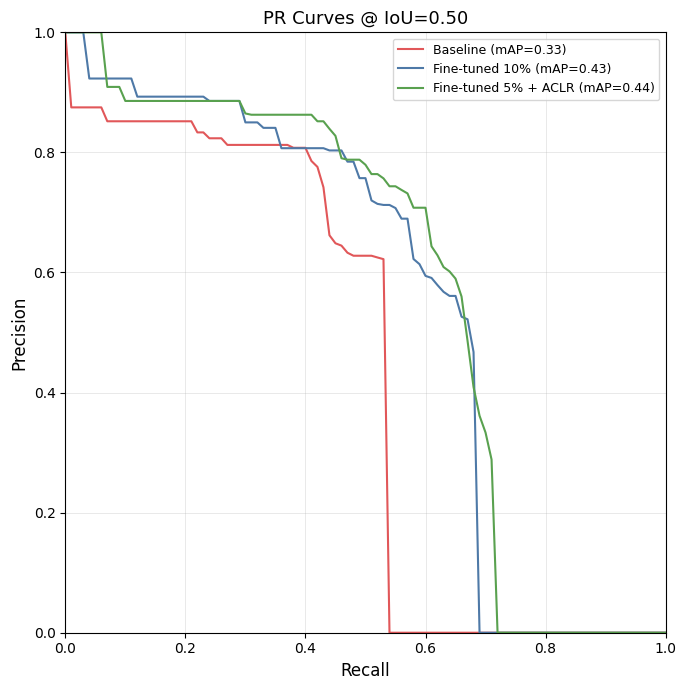

In [29]:

IOU_IDX = 0  # index 0 = IoU 0.5

model_labels = {
    "eval_baseline_s10":  "Baseline",
    "eval_ft_s10":        "Fine-tuned 10%",
    "eval_ft_aclr_s10":   "Fine-tuned 5% + ACLR",
}
colors = ["#e15759", "#4e79a7", "#59a14f"]

fig, ax = plt.subplots(figsize=(12, 7))

for (eval_key, label), color in zip(model_labels.items(), colors):
    res  = results[eval_key]
    prec = res.precision[IOU_IDX, 0, :]
    rec  = res.recall
    valid = prec >= 0
    ap = res.mAP()
    ax.plot(rec[valid], prec[valid], color=color, linewidth=1.5, label=f"{label} (mAP={ap:.2f})")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("PR Curves @ IoU=0.50", fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

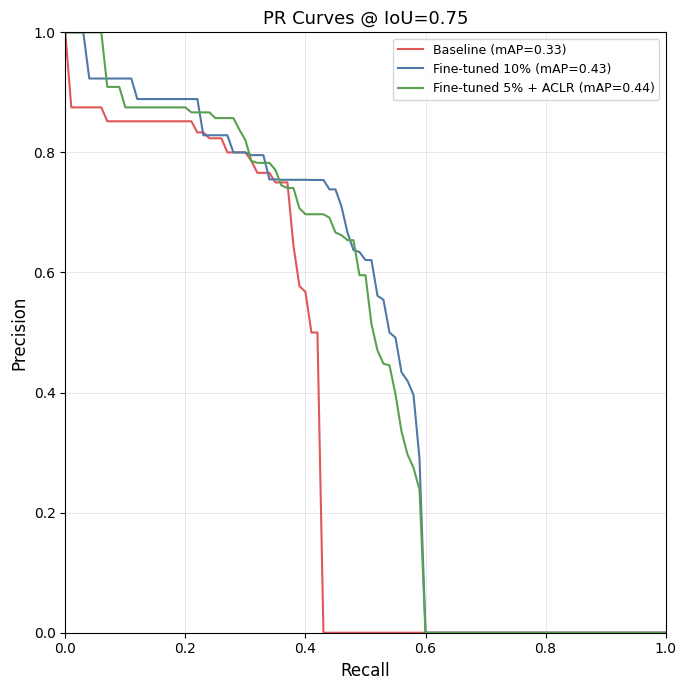

In [30]:
IOU_IDX = 6 # index 0 = IoU 0.75

model_labels = {
    "eval_baseline_s10":  "Baseline",
    "eval_ft_s10":        "Fine-tuned 10%",
    "eval_ft_aclr_s10":   "Fine-tuned 5% + ACLR",
}
colors = ["#e15759", "#4e79a7", "#59a14f"]

fig, ax = plt.subplots(figsize=(12, 7))

for (eval_key, label), color in zip(model_labels.items(), colors):
    res  = results[eval_key]
    prec = res.precision[IOU_IDX, 0, :]
    rec  = res.recall
    valid = prec >= 0
    ap = res.mAP()
    ax.plot(rec[valid], prec[valid], color=color, linewidth=1.5, label=f"{label} (mAP={ap:.2f})")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("PR Curves @ IoU=0.75", fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("pr_curves_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Non Maximum Supression

NMS applied with IoU 0.35

In [31]:
# Reload evaluation
models = [
    {
        "pred_field": "NNN_predWP_SEED10_nms",
        "eval_key":   "eval_baseline_s10_nms",
    },
    {
        "pred_field": "NWW_partition_4_SEED10_augm_0424_1304_nms",
        "eval_key":   "eval_ft_s10_nms",
    },
    {
        "pred_field": "NWW_ACLR_partition_4_SEED10_augm_0425_0240_nms",
        "eval_key":   "eval_ft_aclr_s10_nms",
    },
]
results = {}
for model in models:
    results[model['eval_key']] = dataset.load_evaluation_results(model['eval_key'])

In [34]:
models = [
    {
        "pred_field": "NNN_predWP_SEED10_nms",
        "eval_key":   "eval_baseline_s10_nms",
    },
    {
        "pred_field": "NWW_partition_4_SEED10_augm_0424_1304_nms",
        "eval_key":   "eval_ft_s10_nms",
    },
    {
        "pred_field": "NWW_ACLR_partition_4_SEED10_augm_0425_0240_nms",
        "eval_key":   "eval_ft_aclr_s10_nms",
    },
]

# --- Run evaluations ---
results = {}
for m in models:
    results[m["eval_key"]] = wp_test_set.evaluate_detections(
        m["pred_field"],
        gt_field="ground_truth",
        eval_key=m["eval_key"],
        method="coco",          # COCO-style mAP
        iou=0.5,
        classwise=False,        # single class (dugong), no need to enforce classwise
        compute_mAP=True,
    )

Evaluating detections...
 100% |███████████████████| 59/59 [514.7ms elapsed, 0s remaining, 114.6 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 59/59 [429.9ms elapsed, 0s remaining, 137.2 samples/s]      
Evaluating detections...
 100% |███████████████████| 59/59 [409.7ms elapsed, 0s remaining, 144.0 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 59/59 [371.5ms elapsed, 0s remaining, 158.8 samples/s]      
Evaluating detections...
 100% |███████████████████| 59/59 [393.0ms elapsed, 0s remaining, 150.1 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 59/59 [364.4ms elapsed, 0s remaining, 161.9 samples/s]      


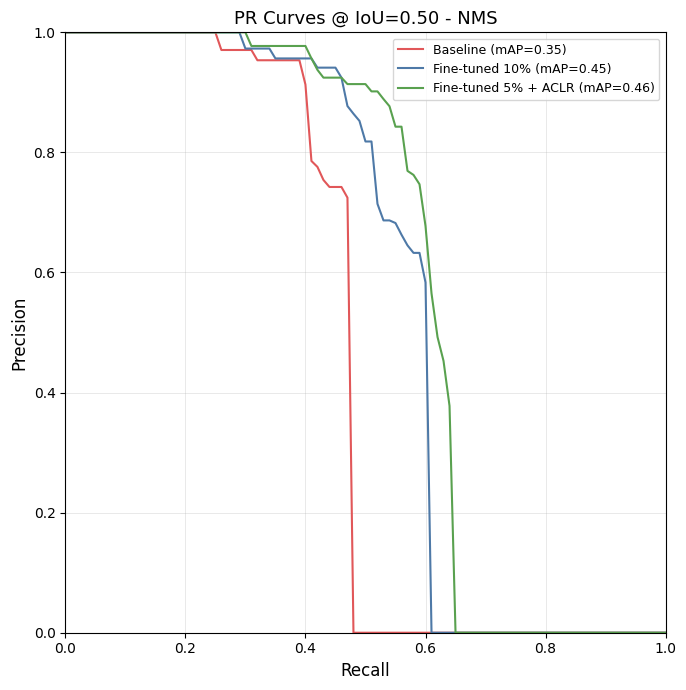

In [32]:
IOU_IDX = 0  # index 0 = IoU 0.5

model_labels = {
    "eval_baseline_s10_nms":  "Baseline",
    "eval_ft_s10_nms":        "Fine-tuned 10%",
    "eval_ft_aclr_s10_nms":   "Fine-tuned 5% + ACLR",
}
colors = ["#e15759", "#4e79a7", "#59a14f"]

fig, ax = plt.subplots(figsize=(12, 7))

for (eval_key, label), color in zip(model_labels.items(), colors):
    res  = results[eval_key]
    prec = res.precision[IOU_IDX, 0, :]
    rec  = res.recall
    valid = prec >= 0
    ap = res.mAP()
    ax.plot(rec[valid], prec[valid], color=color, linewidth=1.5, label=f"{label} (mAP={ap:.2f})")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("PR Curves @ IoU=0.50 - NMS", fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.set_aspect("equal")

plt.tight_layout()
#plt.savefig("pr_curves_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
dataset.delete_evaluations()

In [16]:
print(wp_test_set.count_values("ground_truth.detections.label"))

{'Dugong': 105}


## Comparing IoU threholds

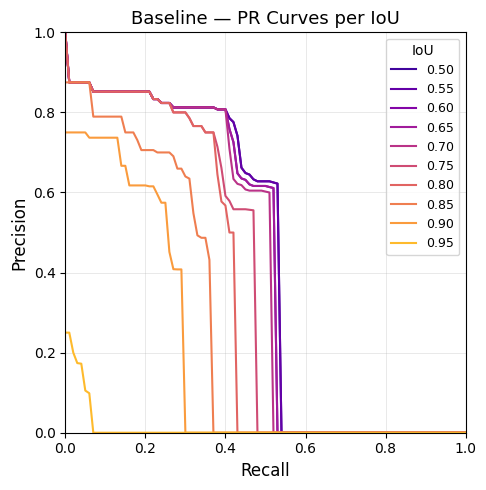

In [ ]:

iou_threshs = results.config.iou_threshs

fig, ax = plt.subplots(figsize=(6, 5))

cmap = plt.cm.plasma
colors = cmap(np.linspace(0.1, 0.85, len(iou_threshs)))

for i, (iou, color) in enumerate(zip(iou_threshs, colors)):
    prec = results.precision[i, 0, :]
    rec  = results.recall

    valid = prec >= 0
    ax.plot(rec[valid], prec[valid], color=color, linewidth=1.5, label=f"{iou:.2f}")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Baseline — PR Curves per IoU", fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(title="IoU", fontsize=9, title_fontsize=10, loc="upper right")
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.set_aspect("equal")

plt.tight_layout()
#plt.savefig("pr_curves_baseline.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Area Size of predictions

In [ ]:
def get_box_areas(wp_test_set, eval_key, pred_field):
    patches = wp_test_set.to_evaluation_patches(eval_key)
    
    tp_areas, fn_areas, fp_areas = [], [], []
    
    for patch in patches.iter_samples():
        if patch.type == "tp":
            boxes = patch.ground_truth.detections
            for det in boxes:
                w, h = det.bounding_box[2], det.bounding_box[3]
                tp_areas.append(w * h)
        elif patch.type == "fn":
            boxes = patch.ground_truth.detections
            for det in boxes:
                w, h = det.bounding_box[2], det.bounding_box[3]
                fn_areas.append(w * h)
        elif patch.type == "fp":
            boxes = patch[pred_field].detections
            for det in boxes:
                w, h = det.bounding_box[2], det.bounding_box[3]
                fp_areas.append(w * h)
    
    return np.array(tp_areas), np.array(fn_areas), np.array(fp_areas)

models = {
    "Baseline (NC→WP)":  ("eval_baseline_s10", "NNN_predWP_SEED10_raw"),
    "Fine-tuned":         ("eval_ft_s10",       "NWW_partition_4_SEED10_augm_0424_1304_raw"),
    "Fine-tuned + ACLR":  ("eval_ft_aclr_s10",  "NWW_ACLR_partition_4_SEED10_augm_0425_0240_raw"),
}

data = {}
for label, (eval_key, pred_field) in models.items():
    tp, fn, fp = get_box_areas(wp_test_set, eval_key, pred_field)
    data[label] = {"tp": tp, "fn": fn, "fp": fp}
    print(f"\n{label}")
    print(f"  TP areas — mean: {tp.mean():.5f}, median: {np.median(tp):.5f}, n={len(tp)}")
    print(f"  FN areas — mean: {fn.mean():.5f}, median: {np.median(fn):.5f}, n={len(fn)}")


Baseline (NC→WP)
  TP areas — mean: 0.00125, median: 0.00103, n=56
  FN areas — mean: 0.00104, median: 0.00073, n=49

Fine-tuned
  TP areas — mean: 0.00136, median: 0.00141, n=72
  FN areas — mean: 0.00070, median: 0.00048, n=33

Fine-tuned + ACLR
  TP areas — mean: 0.00136, median: 0.00140, n=75
  FN areas — mean: 0.00064, median: 0.00047, n=30



Baseline (NC-WP)
  TP areas — mean: 0.00125, median: 0.00103, n=56
  FN areas — mean: 0.00104, median: 0.00073, n=49

Fine-tuned
  TP areas — mean: 0.00136, median: 0.00141, n=72
  FN areas — mean: 0.00070, median: 0.00048, n=33

Fine-tuned + ACLR
  TP areas — mean: 0.00136, median: 0.00140, n=75
  FN areas — mean: 0.00064, median: 0.00047, n=30


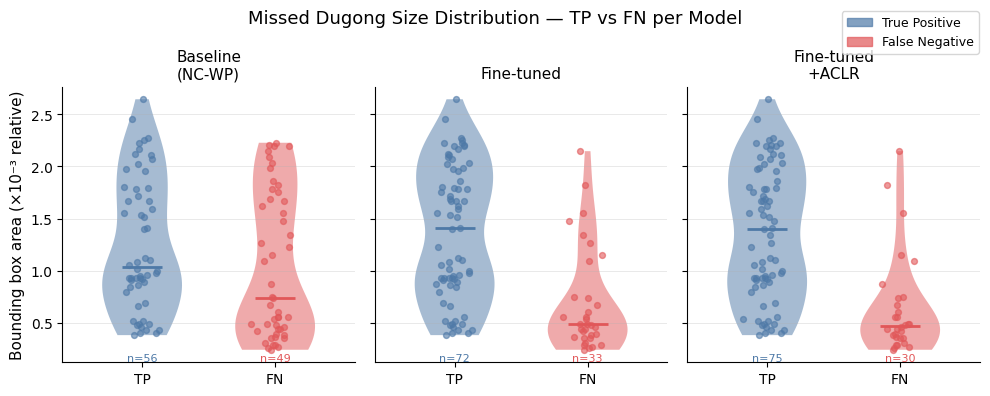

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


models = {
    "Baseline (NC-WP)":  ("eval_baseline_s10", "NNN_predWP_SEED10_raw"),
    "Fine-tuned":         ("eval_ft_s10",       "NWW_partition_4_SEED10_augm_0424_1304_raw"),
    "Fine-tuned + ACLR":  ("eval_ft_aclr_s10",  "NWW_ACLR_partition_4_SEED10_augm_0425_0240_raw"),
}

data = {}
for label, (eval_key, pred_field) in models.items():
    tp, fn, fp = get_box_areas(wp_test_set, eval_key, pred_field)
    data[label] = {"tp": tp, "fn": fn, "fp": fp}
    print(f"\n{label}")
    print(f"  TP areas — mean: {tp.mean():.5f}, median: {np.median(tp):.5f}, n={len(tp)}")
    print(f"  FN areas — mean: {fn.mean():.5f}, median: {np.median(fn):.5f}, n={len(fn)}")

data = {
    "Baseline\n(NC-WP)": {
        "tp": data["Baseline (NC-WP)"]["tp"],
        "fn": data["Baseline (NC-WP)"]["fn"],
    },
    "Fine-tuned": {
        "tp": data["Fine-tuned"]["tp"],
        "fn": data["Fine-tuned"]["fn"],
    },
    "Fine-tuned\n+ACLR": {
        "tp": data["Fine-tuned + ACLR"]["tp"],
        "fn": data["Fine-tuned + ACLR"]["fn"],
    },
}

model_names = list(data.keys())
n_models = len(model_names)

COLOR_TP = "#4e79a7"
COLOR_FN = "#e15759"

fig, axes = plt.subplots(1, n_models, figsize=(10, 4), sharey=True)

for ax, (model_name, vals) in zip(axes, data.items()):
    tp_areas = vals["tp"] * 1000   # scale for readability
    fn_areas = vals["fn"] * 1000

    # Violin plots
    vp_tp = ax.violinplot([tp_areas], positions=[0], widths=0.6,
                           showmedians=True, showextrema=False)
    vp_fn = ax.violinplot([fn_areas], positions=[1], widths=0.6,
                           showmedians=True, showextrema=False)

    # Style TP violin
    for pc in vp_tp["bodies"]:
        pc.set_facecolor(COLOR_TP)
        pc.set_alpha(0.5)
    vp_tp["cmedians"].set_color(COLOR_TP)
    vp_tp["cmedians"].set_linewidth(2)

    # Style FN violin
    for pc in vp_fn["bodies"]:
        pc.set_facecolor(COLOR_FN)
        pc.set_alpha(0.5)
    vp_fn["cmedians"].set_color(COLOR_FN)
    vp_fn["cmedians"].set_linewidth(2)

    # Strip plot (jittered points)
    np.random.seed(42)
    ax.scatter(np.random.normal(0, 0.07, len(tp_areas)), tp_areas,
               color=COLOR_TP, alpha=0.6, s=18, zorder=3)
    ax.scatter(np.random.normal(1, 0.07, len(fn_areas)), fn_areas,
               color=COLOR_FN, alpha=0.6, s=18, zorder=3)

    # Annotate n
    ax.text(0, +0.005, f"n={len(tp_areas)}", ha="center", fontsize=8,
            color=COLOR_TP, transform=ax.get_xaxis_transform())
    ax.text(1, +0.005, f"n={len(fn_areas)}", ha="center", fontsize=8,
            color=COLOR_FN, transform=ax.get_xaxis_transform())

    ax.set_title(model_name, fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["TP", "FN"], fontsize=10)
    ax.set_xlim(-0.6, 1.6)
    ax.grid(True, axis="y", linewidth=0.4, alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Bounding box area (×10⁻³ relative)", fontsize=11)

legend_handles = [
    mpatches.Patch(color=COLOR_TP, alpha=0.7, label="True Positive"),
    mpatches.Patch(color=COLOR_FN, alpha=0.7, label="False Negative"),
]
fig.legend(handles=legend_handles, fontsize=9,
           loc="upper right", bbox_to_anchor=(0.99, 0.99))

fig.suptitle("Missed Dugong Size Distribution — TP vs FN per Model", fontsize=13)
plt.tight_layout()
#plt.savefig("fn_size_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()

- The shrinking FN violin across models visually tells that fine-tuning recovers medium-sized missed dugongs, leaving only the irreducibly small ones as FN
- The model struggles to recognize small bbox GT, where most of it comes from calf dugongs!

## Confidence Score Distribution

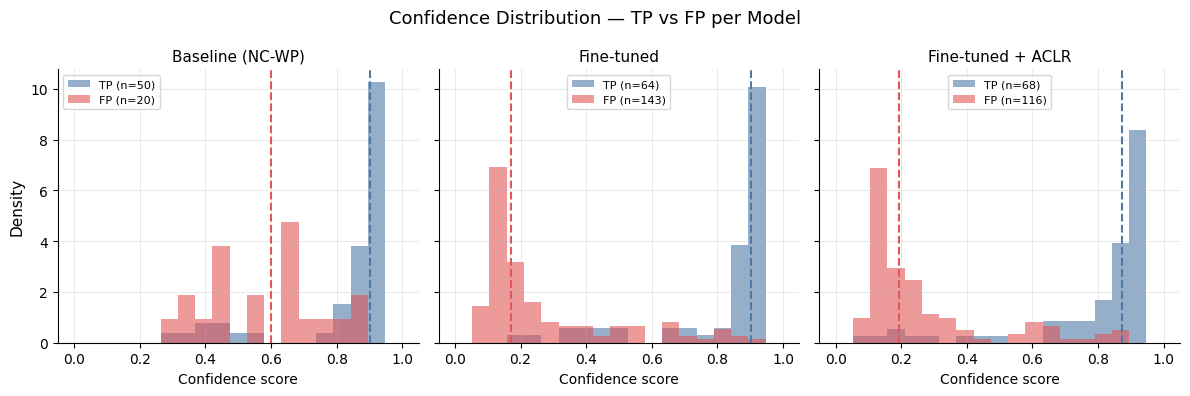

In [50]:

model_labels = {
    "eval_baseline_s10_nms": "Baseline (NC-WP)",
    "eval_ft_s10_nms":       "Fine-tuned",
    "eval_ft_aclr_s10_nms":  "Fine-tuned + ACLR",
}

COLOR_TP = "#4e79a7"
COLOR_FP = "#e15759"

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)

for ax, (eval_key, label) in zip(axes, model_labels.items()):
    res   = results[eval_key]
    ytrue = np.array(res.ytrue)
    confs = np.array([v if v is not None else np.nan for v in res.confs], dtype=float)
    ious  = np.array([v if v is not None else 0.0    for v in res.ious],  dtype=float)

    pred_mask = ~np.isnan(confs)  # only actual predictions
    tp_confs  = confs[pred_mask & (ytrue == "Dugong") & (ious >= 0.5)]
    fp_confs  = confs[pred_mask & (ytrue == "(none)")]

    bins = np.linspace(0, 1, 20)
    ax.hist(tp_confs, bins=bins, color=COLOR_TP, alpha=0.6, label=f"TP (n={len(tp_confs)})", density=True)
    ax.hist(fp_confs, bins=bins, color=COLOR_FP, alpha=0.6, label=f"FP (n={len(fp_confs)})", density=True)

    ax.axvline(np.median(tp_confs), color=COLOR_TP, linewidth=1.5, linestyle="--")
    ax.axvline(np.median(fp_confs), color=COLOR_FP, linewidth=1.5, linestyle="--")

    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Confidence score", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Density", fontsize=11)
fig.suptitle("Confidence Distribution — TP vs FP per Model", fontsize=13)
plt.tight_layout()
#plt.savefig("confidence_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Per Sample F1 distribution

eval_baseline_s10 — mean F1: 0.486, median: 0.667
eval_ft_s10 — mean F1: 0.456, median: 0.444
eval_ft_aclr_s10 — mean F1: 0.493, median: 0.444


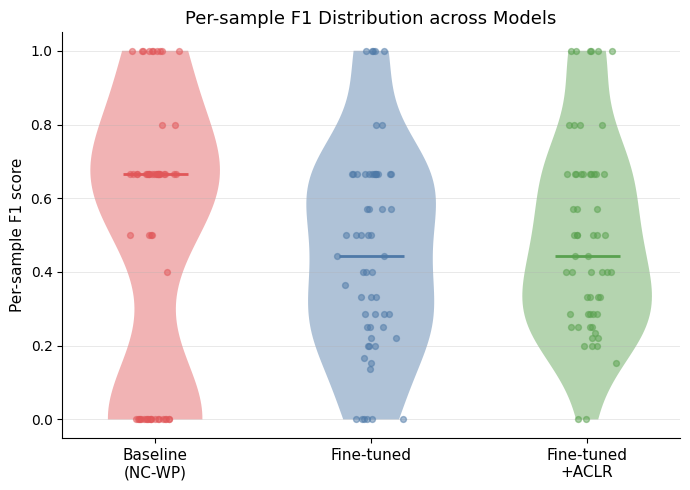

In [ ]:

model_labels = {
    "eval_baseline_s10": "Baseline\n(NC-WP)",
    "eval_ft_s10":       "Fine-tuned",
    "eval_ft_aclr_s10":  "Fine-tuned\n+ACLR",
}
colors = ["#e15759", "#4e79a7", "#59a14f"]

fig, ax = plt.subplots(figsize=(7, 5))

f1_data = []
for eval_key in model_labels:
    tp = np.array(wp_test_set.values(f"{eval_key}_tp"), dtype=float)
    fp = np.array(wp_test_set.values(f"{eval_key}_fp"), dtype=float)
    fn = np.array(wp_test_set.values(f"{eval_key}_fn"), dtype=float)
    f1 = 2*tp / (2*tp + fp + fn + 1e-9)
    f1_data.append(f1)
    print(f"{eval_key} — mean F1: {f1.mean():.3f}, median: {np.median(f1):.3f}")

positions = [0, 1, 2]
vp = ax.violinplot(f1_data, positions=positions, widths=0.6,
                    showmedians=True, showextrema=False)

for pc, color in zip(vp["bodies"], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.45)
vp["cmedians"].set_colors(colors)
vp["cmedians"].set_linewidth(2)

np.random.seed(42)
for i, (f1, color) in enumerate(zip(f1_data, colors)):
    ax.scatter(np.random.normal(i, 0.06, len(f1)), f1,
               color=color, alpha=0.5, s=18, zorder=3)

ax.set_xticks(positions)
ax.set_xticklabels(model_labels.values(), fontsize=11)
ax.set_ylabel("Per-sample F1 score", fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.set_title("Per-sample F1 Distribution across Models", fontsize=13)
ax.grid(True, axis="y", linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
#plt.savefig("f1_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()

## GT Count VS Prediction Count

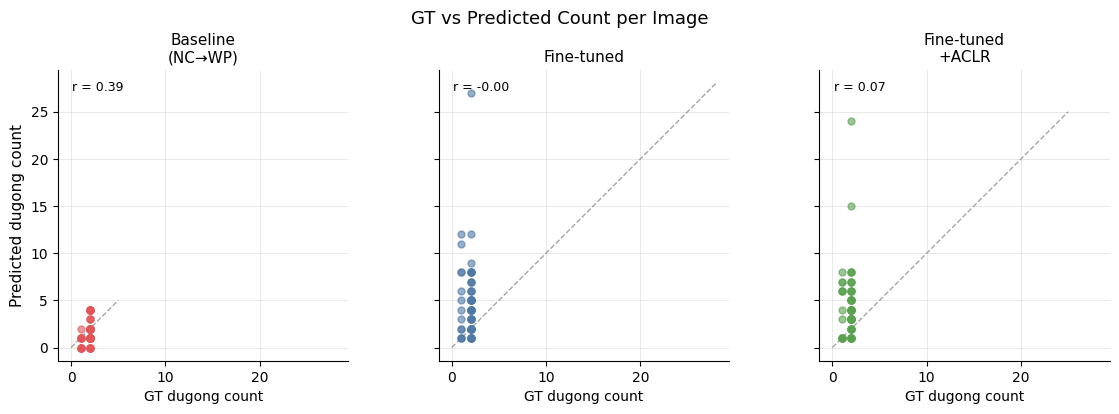

In [52]:
model_info = {
    "Baseline\n(NC→WP)": "NNN_predWP_SEED10_raw",
    "Fine-tuned":         "NWW_partition_4_SEED10_augm_0424_1304_raw",
    "Fine-tuned\n+ACLR":  "NWW_ACLR_partition_4_SEED10_augm_0425_0240_raw",
}
colors = ["#e15759", "#4e79a7", "#59a14f"]

gt_counts = np.array(wp_test_set.values(F("ground_truth.detections").length()))

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

for ax, (label, pred_field), color in zip(axes, model_info.items(), colors):
    pred_counts = np.array(wp_test_set.values(F(f"{pred_field}.detections").length()))

    max_val = max(gt_counts.max(), pred_counts.max()) + 1
    ax.plot([0, max_val], [0, max_val], "--", color="gray",
            linewidth=1, alpha=0.7, label="Perfect")

    ax.scatter(gt_counts, pred_counts, color=color, alpha=0.6, s=25, zorder=3)

    # Correlation
    corr = np.corrcoef(gt_counts, pred_counts)[0, 1]
    ax.text(0.05, 0.93, f"r = {corr:.2f}", transform=ax.transAxes,
            fontsize=9, color="black")

    ax.set_title(label, fontsize=11)
    ax.set_xlabel("GT dugong count", fontsize=10)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_aspect("equal")

axes[0].set_ylabel("Predicted dugong count", fontsize=11)
fig.suptitle("GT vs Predicted Count per Image", fontsize=13)
plt.tight_layout()
plt.savefig("gt_vs_pred_count.pdf", dpi=300, bbox_inches="tight")
plt.show()